In [134]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))

print(f'Working directory: {cwd}')

Working directory: G:\My Drive\projects\Green_Tom\rat-frustration\rat-model


In [ ]:
import pandas as pd
import pickle
import numpy as np
import os
import xgboost as xgb
from tqdm import tqdm
from modules.manuscript_utils import calc_metrics

output_base = 'output/data' 
df_ML = pickle.load(open(f'{output_base}/df_ML.pkl', "rb"))
df_ML_train = pickle.load(open(f'{output_base}/df_ML_train.pkl', "rb"))
df_ML_test = pickle.load(open(f'{output_base}/df_ML_test.pkl', "rb"))
# df_ML_unscaled = pickle.load(open(f'{output_base}/df_ML_unscaled.pkl', "rb"))
ML_feature_names = pickle.load(open(f'{output_base}/ML_feature_names.pkl', "rb"))
barpress_features_names = pickle.load(open(f'{output_base}/barpress_features_names.pkl', "rb"))


figure_path = 'output/figures'
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

In [136]:

from collections import OrderedDict


feature_name_map = OrderedDict([
    ('max_force', 'Max Force'),
    ('force_variation_rate', 'Force Variation Rate'),
    ('avg_first_5', 'Average First 5 Samples'),
    ('avg_last_5', 'Average Last 5 Samples'),
    ('pk_sharp_max', 'Max Peak Sharpness'),
    ('pk_sharp_mean', 'Mean Peak Sharpness'),
    ('pk_sharp_min', 'Min Peak Sharpness'),
    ('skewness', 'Skewness'),
    ('kurtosis', 'Kurtosis'),
    ('total_press_duration', 'Press Duration'),
    # ('gaps', 'Gap duration'),
    ('pk_num', 'Peak Number'),
    ('pk_widths_max', 'Max Peak Width'),
    ('pk_widths_mean', 'Mean Peak Width'),
    ('pk_widths_min', 'Min Peak Width')
])

if set(barpress_features_names) != set(feature_name_map.keys()):
    raise ValueError("The keys of feature_name_map must match the barpress_features_names.")


ordered_features = list(feature_name_map.keys())
ordered_features


['max_force',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'total_press_duration',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min']

# Univariate analysis

## Across-rat feature performance

In [137]:
from sklearn.model_selection import GroupKFold, cross_val_score

id_col = 'id'
label_col = 'label'
features_for_auc = [f for f in ordered_features if f in df_ML_train.columns]

# One-feature models evaluated with 10-fold grouped cross-validation by rat.
feature_groupkfold_rows = []

for feat in tqdm(features_for_auc, desc="10-fold grouped CV"):
    feature_df = df_ML_train[[id_col, label_col, feat, 'sample_weight']].dropna().copy()
    X = feature_df[[feat]]
    y = feature_df[label_col]
    groups = feature_df[id_col]
    sample_weights = feature_df['sample_weight'].to_numpy()

    cv = GroupKFold(n_splits=10)
    model = xgb.XGBClassifier(
        tree_method="hist",
        random_state=42
    )

    fold_aucs = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        groups=groups,
        scoring="roc_auc",
        params={"sample_weight": sample_weights}
    )

    for fold_idx, fold_auc in enumerate(fold_aucs, start=1):
        feature_groupkfold_rows.append({
            'Feature': feat,
            'Fold': fold_idx,
            'AUC': float(fold_auc)
        })

df_feature_groupkfold = pd.DataFrame(feature_groupkfold_rows)
df_feature_groupkfold_summary = (
    df_feature_groupkfold
    .groupby('Feature', as_index=False)
    .agg(
        N_folds=('AUC', 'count'),
        AUC_mean=('AUC', 'mean'),
        AUC_sd=('AUC', 'std')
    )
)

df_feature_groupkfold_summary['Feature'] = (
    df_feature_groupkfold_summary['Feature']
    .map(feature_name_map)
    .fillna(df_feature_groupkfold_summary['Feature'])
)
df_feature_groupkfold_summary['CI95'] = 1.96 * (
    df_feature_groupkfold_summary['AUC_sd'] / np.sqrt(df_feature_groupkfold_summary['N_folds'])
)
df_feature_groupkfold_summary = (
    df_feature_groupkfold_summary
    .sort_values('AUC_mean', ascending=False)
    .reset_index(drop=True)
)

display_cols = ['AUC_mean', 'AUC_sd', 'CI95']
df_feature_groupkfold_display = df_feature_groupkfold_summary.copy()
for c in display_cols:
    df_feature_groupkfold_display[c] = df_feature_groupkfold_display[c].round(3)

display(df_feature_groupkfold_display)


10-fold grouped CV: 100%|██████████| 14/14 [00:15<00:00,  1.09s/it]


,Feature,N_folds,AUC_mean,AUC_sd,CI95
0,Press Duration,10,0.581,0.026,0.016
1,Peak Number,10,0.565,0.021,0.013
2,Max Force,10,0.551,0.037,0.023
3,Max Peak Width,10,0.551,0.023,0.014
4,Force Variation Rate,10,0.542,0.040,0.025
5,Kurtosis,10,0.533,0.016,0.010
6,Min Peak Width,10,0.527,0.017,0.011
7,Mean Peak Width,10,0.527,0.023,0.014
8,Average Last 5 Samples,10,0.523,0.023,0.014
9,Min Peak Sharpness,10,0.522,0.034,0.021


## Feature performance plot

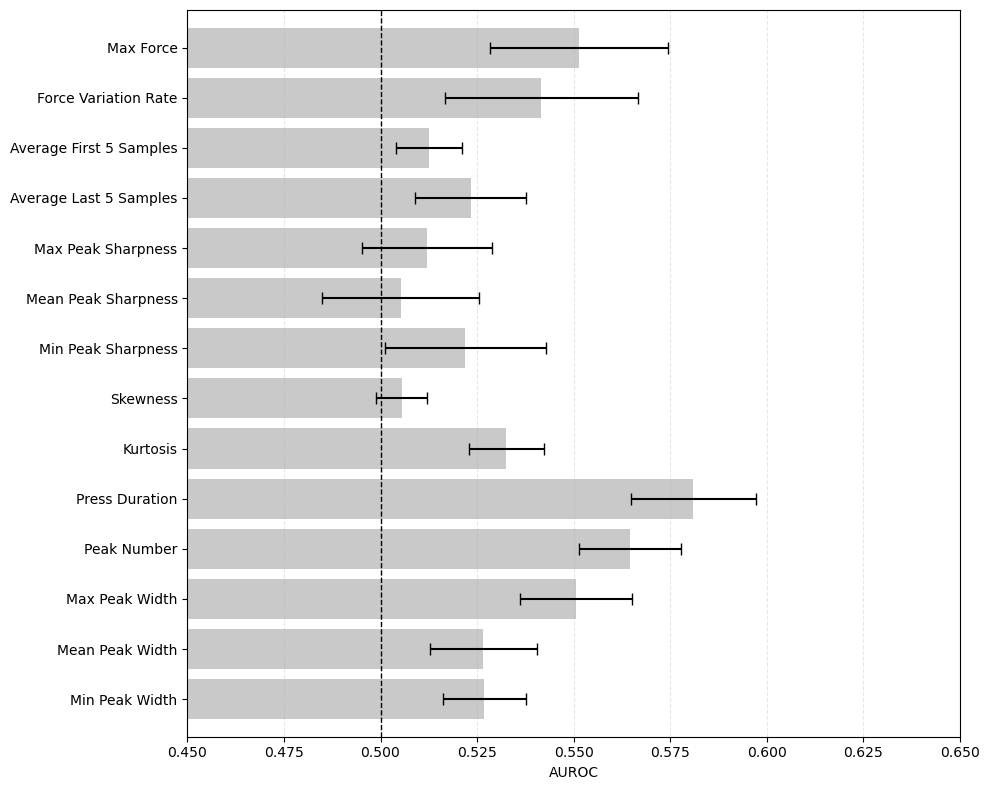

In [138]:
import matplotlib.pyplot as plt
from PIL import Image

plot_df = df_feature_groupkfold_summary.copy()

feature_order = [
    feature_name_map[f]
    for f in ordered_features
    if feature_name_map[f] in plot_df['Feature'].values
]
plot_order = feature_order[::-1]

plot_vals = (
    plot_df
    .set_index('Feature')
    .reindex(plot_order)
    .reset_index()
)

y = np.arange(len(plot_order))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    y,
    plot_vals['AUC_mean'],
    xerr=plot_vals['CI95'],
    capsize=4,
    color='#c9c9c9'
)

ax.set_yticks(y)
ax.set_yticklabels(plot_order)
ax.set_xlabel('AUROC')
ax.set_xlim(0.45, 0.65)
ax.set_ylim(-0.75, len(plot_order) - 0.25)
ax.axvline(0.5, linestyle='--', color='black', linewidth=1)
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

output_path = f"{figure_path}/feature_performance.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

with Image.open(output_path) as img:
    img = img.convert('RGB')
    bottom_pad_px = max(1, int(img.height * 0.08))
    padded_img = Image.new(
        'RGB',
        (img.width, img.height + bottom_pad_px),
        'white'
    )
    padded_img.paste(img, (0, 0))
    padded_img.save(output_path)

plt.show()


# GB

In [ ]:
fit_feature_names = [
    f for f in ML_feature_names
    if f not in ['force_variation_rate', 'pk_sharp_max', 'pk_sharp_min']
]
x_train = df_ML_train.loc[:, fit_feature_names]
y_train = df_ML_train.loc[:, 'label'].values
sample_weights_train = df_ML_train['sample_weight'].values
x_test = df_ML_test.loc[:, fit_feature_names]
y_test = df_ML_test.loc[:, 'label'].values
sample_weights_test = df_ML_test['sample_weight'].values


In [140]:
import xgboost as xgb

gb = xgb.XGBClassifier(
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.6,
    reg_lambda=10,
    tree_method="hist",
    random_state=42
)

gb.fit(x_train, y_train, sample_weight=sample_weights_train)


y_pred = gb.predict_proba(x_test)[:, 1]
df_ML_test["gb_prob"] = y_pred
GB_metrics = calc_metrics(y_test, y_pred, sample_weight=sample_weights_test)
print(GB_metrics)


{'threshold': 0.328, 'f1_score': 0.677, 'recall': 0.92, 'precision': 0.536, 'auc': 0.661}


In [141]:
# Will not be used in the manuscript
# feature importance
import matplotlib.pyplot as plt
importance = gb.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': fit_feature_names,
    'Importance': importance
})

feature_importance_df['Feature'] = feature_importance_df['Feature'].map(feature_name_map).fillna(feature_importance_df['Feature'])
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
display(feature_importance_df)

,Feature,Importance
0,Press Duration,0.149389
1,sex,0.084029
2,age,0.078414
3,Peak Number,0.076478
4,weight,0.070284
5,Average First 5 Samples,0.063709
6,Min Peak Width,0.061646
7,Max Peak Width,0.060629
8,Max Force,0.058616
9,Average Last 5 Samples,0.058297


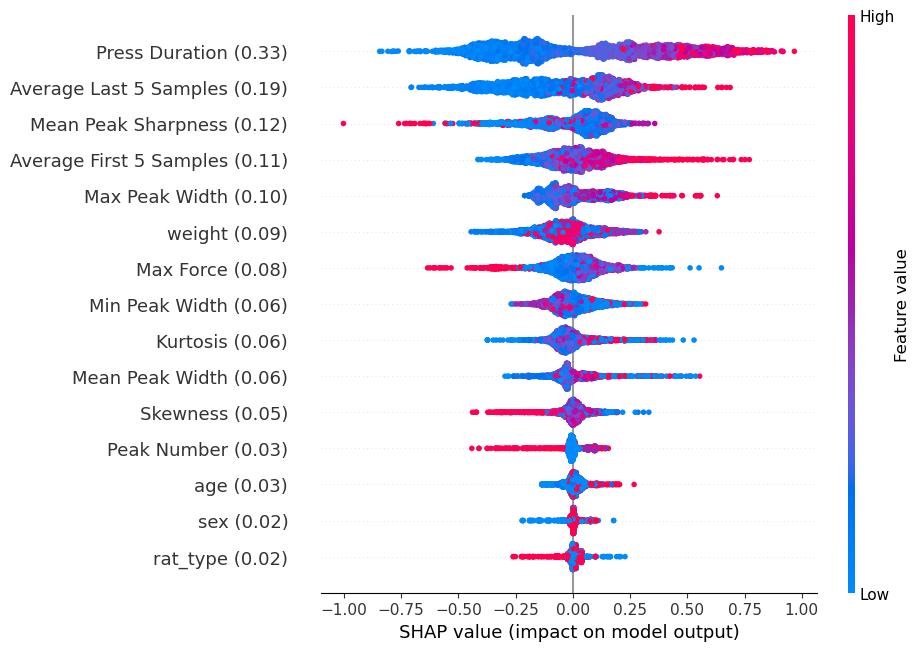

In [142]:
import shap
import numpy as np
import matplotlib.pyplot as plt

expl_gb = shap.TreeExplainer(gb)
shap_values = expl_gb(x_test)
mean_shap = np.abs(shap_values.values).mean(axis=0)

shap_values.feature_names = [
    f"{feature_name_map.get(name, name)} ({mean_shap[i]:.2f})"
    for i, name in enumerate(x_test.columns)
]

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=30, show=False)

fig = plt.gcf()
fig.savefig(f"{figure_path}/shap_plot_GB.png", dpi=300, bbox_inches="tight")
plt.show()

In [143]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
# set seed
np.random.seed(42)

# --- Baseline ---
baseline_auc = roc_auc_score(y_test, gb.predict_proba(x_test)[:, 1], sample_weight=sample_weights_test)

# Working copy
X_perm = x_test.copy()

# Remaining features
remaining_features = fit_feature_names.copy()

# Store results
sequential_results = []

# Add baseline row
sequential_results.append({
    'Step': 0,
    'Feature Removed': 'BASELINE',
    'AUC': baseline_auc,
    'Marginal AUC Drop': 0.0,
    'Cumulative AUC Drop': 0.0
})

current_auc = baseline_auc

print(f"Baseline AUC: {baseline_auc:.6f}")

# --- Sequential permutation elimination ---
step = 1

while len(remaining_features) > 0:

    feature_drops = []

    # Evaluate each remaining feature
    for feature in remaining_features:

        X_temp = X_perm.copy()

        # Temporarily permute feature
        X_temp[feature] = np.random.permutation(
            X_temp[feature].values
        )

        perm_auc = roc_auc_score(
            y_test,
            gb.predict_proba(X_temp)[:, 1],
            sample_weight=sample_weights_test
        )

        auc_drop = current_auc - perm_auc

        feature_drops.append({
            'Feature': feature,
            'Permuted AUC': perm_auc,
            'AUC Drop': auc_drop
        })

    feature_drops_df = pd.DataFrame(feature_drops)

    # Select feature with largest drop
    worst_row = feature_drops_df.sort_values(
        'AUC Drop',
        ascending=False
    ).iloc[0]

    selected_feature = worst_row['Feature']

    # Permanently permute selected feature
    X_perm[selected_feature] = np.random.permutation(
        X_perm[selected_feature].values
    )

    # Recompute current AUC
    current_auc = roc_auc_score(
        y_test,
        gb.predict_proba(X_perm)[:, 1],
        sample_weight=sample_weights_test
    )

    cumulative_drop = baseline_auc - current_auc

    sequential_results.append({
        'Step': step,
        'Feature Removed': selected_feature,
        'AUC': current_auc,
        'Marginal AUC Drop': worst_row['AUC Drop'],
        'Cumulative AUC Drop': cumulative_drop
    })

    print(
        f"Step {step:2d} | "
        f"Removed: {selected_feature:30s} | "
        f"AUC: {current_auc:.6f} | "
        f"Marginal Drop: {worst_row['AUC Drop']:.6f}"
    )

    remaining_features.remove(selected_feature)
    step += 1

# --- Final dataframe ---
sequential_auc_df = pd.DataFrame(sequential_results)

# Optional pretty feature names
sequential_auc_df['Feature Removed'] = (
    sequential_auc_df['Feature Removed']
    .map(feature_name_map)
    .fillna(sequential_auc_df['Feature Removed'])
)

display(sequential_auc_df)

Baseline AUC: 0.660610
Step  1 | Removed: total_press_duration           | AUC: 0.582099 | Marginal Drop: 0.081649
Step  2 | Removed: avg_last_5                     | AUC: 0.568776 | Marginal Drop: 0.023895
Step  3 | Removed: pk_sharp_mean                  | AUC: 0.543246 | Marginal Drop: 0.017143
Step  4 | Removed: max_force                      | AUC: 0.526839 | Marginal Drop: 0.016407
Step  5 | Removed: kurtosis                       | AUC: 0.518088 | Marginal Drop: 0.010211
Step  6 | Removed: pk_widths_max                  | AUC: 0.519359 | Marginal Drop: 0.009979
Step  7 | Removed: avg_first_5                    | AUC: 0.507091 | Marginal Drop: 0.010179
Step  8 | Removed: pk_widths_min                  | AUC: 0.503470 | Marginal Drop: 0.006620
Step  9 | Removed: pk_widths_mean                 | AUC: 0.498414 | Marginal Drop: 0.004868
Step 10 | Removed: age                            | AUC: 0.495279 | Marginal Drop: 0.006918
Step 11 | Removed: pk_num                         | AUC: 

,Step,Feature Removed,AUC,Marginal AUC Drop,Cumulative AUC Drop
0,0,BASELINE,0.660610,0.000000,0.000000
1,1,Press Duration,0.582099,0.081649,0.078511
2,2,Average Last 5 Samples,0.568776,0.023895,0.091834
3,3,Mean Peak Sharpness,0.543246,0.017143,0.117363
4,4,Max Force,0.526839,0.016407,0.133771
5,5,Kurtosis,0.518088,0.010211,0.142521
6,6,Max Peak Width,0.519359,0.009979,0.141251
7,7,Average First 5 Samples,0.507091,0.010179,0.153518
8,8,Min Peak Width,0.503470,0.006620,0.157140
9,9,Mean Peak Width,0.498414,0.004868,0.162196


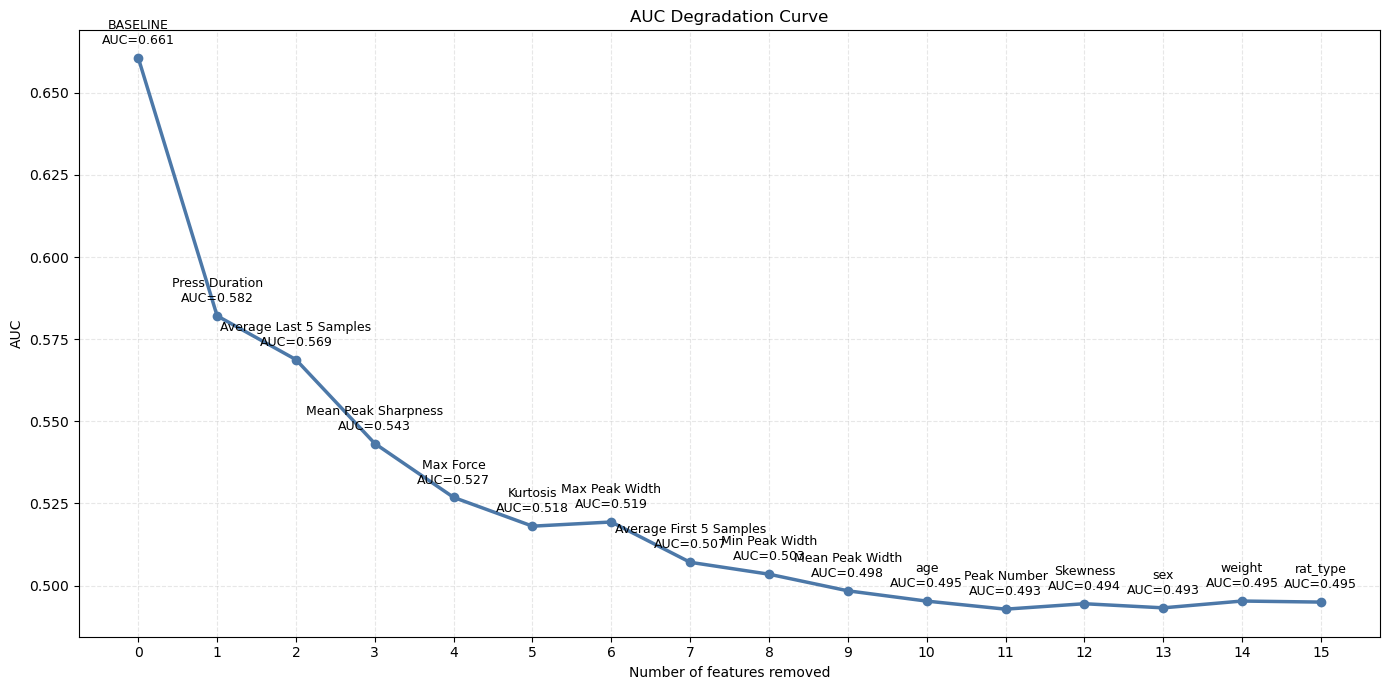

In [144]:
# Line plot of sequential AUC degradation

plt.figure(figsize=(14, 7))

plt.plot(
    sequential_auc_df['Step'],
    sequential_auc_df['AUC'],
    marker='o',
    linewidth=2.5,
    color='#4C78A8'
)

# Annotate AUC values
for _, row in sequential_auc_df.iterrows():

    label = (
        f"{row['Feature Removed']}\n"
        f"AUC={row['AUC']:.3f}"
    )

    plt.annotate(
        label,
        (row['Step'], row['AUC']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

plt.xticks(sequential_auc_df['Step'])

plt.xlabel('Number of features removed')
plt.ylabel('AUC')

plt.title('AUC Degradation Curve')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

output_path = f"{figure_path}/AUC degradation curve.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

# Test dataset

category
EXT    0.151741
FR1    0.143058
dtype: float32

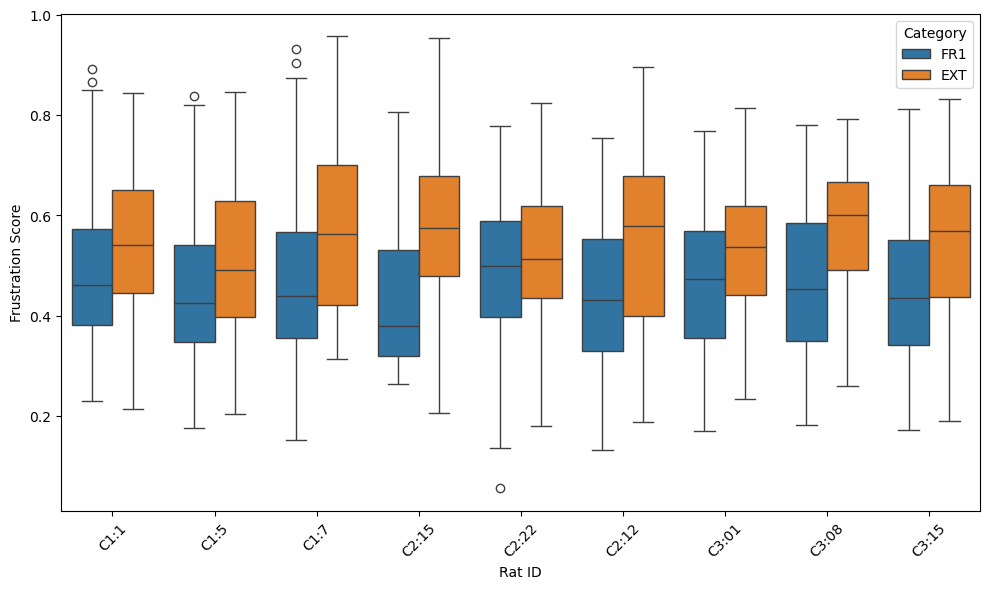

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_ML2 = df_ML_test.copy()
# combine with sex
# df_ML2['id'] = df_ML2.apply(lambda row: f"{row['id']} ({'M' if row['sex'] ==1 else 'F'})", axis=1)
sns.boxplot(
    data=df_ML2,
    x='id',          # group by rat ID
    y='gb_prob',     # probability values
    hue='category',  # FR1 vs EXT
    hue_order=['FR1', 'EXT']
)

# SD by id and category
display(df_ML2.groupby(['id', 'category'])['gb_prob'].std().unstack().mean())

plt.xlabel('Rat ID')
plt.ylabel('Frustration Score')
plt.legend(title='Category')
plt.xticks(rotation=45)

plt.tight_layout()

fig = plt.gcf()
fig.savefig(f"{figure_path}/boxplot_holdout.png", dpi=300, bbox_inches="tight")
plt.show()

In [146]:
df_ML_test.columns

Index(['id', 'category', 'data', 'data_start_index', 'data_end_index',
       'file_name', 'cohort', 'label', 'sample_weight', 'sex', 'age', 'weight',
       'rat_type', 'total_press_duration', 'max_force', 'pk_num',
       'pk_widths_max', 'pk_widths_mean', 'pk_widths_min', 'pk_sharp_max',
       'pk_sharp_mean', 'pk_sharp_min', 'skewness', 'kurtosis',
       'force_variation_rate', 'avg_first_5', 'avg_last_5', 'gb_prob'],
      dtype='object')

In [147]:
import pandas as pd
import numpy as np

def aggregate_prob_by_chunk(
    df,
    chunk_size,
    id_col='id',
    label_col='label',
    file_col='file_name',
    prob_col='gb_prob',
    sample_weight_col='sample_weight'
):
    """
    Aggregate gb_prob by mean within fixed-size chunks.

    Chunking is performed:
    - separately within each (id, label, file_name)
    - after sorting by data_start_index
    - residual rows that do not fill a complete chunk are ignored

    Returns
    -------
    pd.DataFrame
    """

    results = []
    group_cols = [id_col, label_col, file_col]
    
    # Sort first
    df_sorted = df.sort_values(group_cols + ["data_start_index"]).copy()

    # Group by subject, label, and source file
    for _, group in df_sorted.groupby(group_cols):

        group = group.reset_index(drop=True)

        # Number of full chunks
        n_full_chunks = len(group) // chunk_size

        # Ignore residual rows
        usable_rows = n_full_chunks * chunk_size

        if usable_rows == 0:
            continue

        group = group.iloc[:usable_rows].copy()

        # Assign chunk ids
        group['chunk_id'] = (
            np.arange(len(group)) // chunk_size
        )

        # Aggregate
        agg = (
            group.groupby('chunk_id')
            .agg(
                id=(id_col, 'first'),
                label=(label_col, 'first'),
                start_index=("data_start_index", 'min'),
                end_index=("data_end_index", 'max'),
                gb_prob_mean=(prob_col, 'mean'),
                sample_weight=(sample_weight_col, 'sum')
            )
            .reset_index(drop=True)
        )

        results.append(agg)

    if not results:
        return pd.DataFrame(columns=['id', 'label', 'start_index', 'end_index', 'gb_prob_mean', 'sample_weight'])

    return pd.concat(results, ignore_index=True)

In [148]:
chunk_sizes = range(1, 101, 1)
results = []
for chunk_size in tqdm(chunk_sizes, desc="Evaluating chunk sizes"):
    chunked_df = aggregate_prob_by_chunk(
        df_ML_test,
        chunk_size=chunk_size
    )

    metrics = calc_metrics(
        chunked_df['label'],
        chunked_df['gb_prob_mean'],
        sample_weight=chunked_df['sample_weight']
    )

    results.append((chunk_size, metrics['auc']))
chunk_results_df = pd.DataFrame(results, columns=['Chunk Size', 'AUC'])
display(chunk_results_df)

Evaluating chunk sizes: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


,Chunk Size,AUC
0,1,0.661
1,2,0.712
2,3,0.744
3,4,0.771
4,5,0.786
...,...,...
95,96,0.987
96,97,0.983
97,98,0.983
98,99,0.976


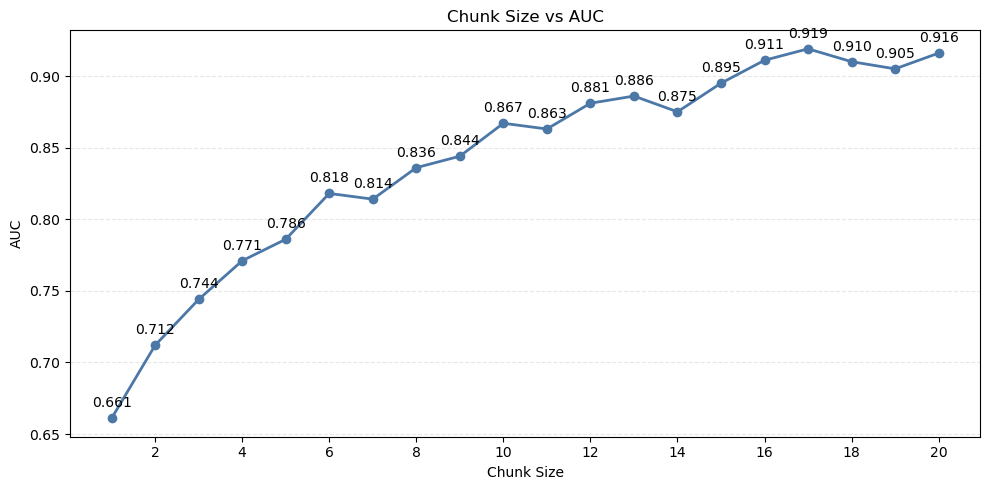

In [149]:
# line plot of chunk size vs AUC
from matplotlib.ticker import MultipleLocator


chunk_results_df2 = chunk_results_df.copy()
chunk_results_df2 = chunk_results_df2[chunk_results_df2['Chunk Size'] <= 20]

plt.figure(figsize=(10, 5))
plt.plot(
    chunk_results_df2['Chunk Size'],
    chunk_results_df2['AUC'],
    marker='o',
    linewidth=2,
    color='#4C78A8'
 )

for chunk_size, auc in zip(chunk_results_df2['Chunk Size'], chunk_results_df2['AUC']):
    plt.annotate(
        f'{auc:.3f}',
        (chunk_size, auc),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )
ax = plt.gca() 
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.xlabel('Chunk Size')
plt.ylabel('AUC')
plt.title('Chunk Size vs AUC')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

fig = plt.gcf()
fig.savefig(f"{figure_path}/auc_by_chunk_size.png", dpi=300, bbox_inches="tight")
plt.show()

# Inference

In [150]:
with open(f'{output_base}/df_app_ML.pkl', 'rb') as f:
    df_app_ML = pickle.load(f)

In [151]:
x_app = df_app_ML.loc[:, fit_feature_names]
y_pred = gb.predict_proba(x_app)[:, 1]
df_app_ML['frustration_probability'] = y_pred
df_app_ML.id.unique()

array(['C3:08', 'C3:15', 'C3:23', 'C3:06', 'C3:05', 'C3:10', 'C3:13',
       'C3:07', 'C3:09', 'C3:20', 'C3:17', 'C3:16', 'C3:12', 'C3:01',
       'C3:21', 'C3:04', 'C3:14', 'C3:19', 'C3:22'], dtype=object)

In [152]:
df_app_ML.columns

Index(['id', 'category', 'data', 'data_start_index', 'data_end_index',
       'file_name', 'cohort', 'sex', 'age', 'weight', 'rat_type',
       'total_press_duration', 'max_force', 'pk_num', 'pk_widths_max',
       'pk_widths_mean', 'pk_widths_min', 'pk_sharp_max', 'pk_sharp_mean',
       'pk_sharp_min', 'skewness', 'kurtosis', 'force_variation_rate',
       'avg_first_5', 'avg_last_5', 'frustration_probability'],
      dtype='object')

In [153]:
df_ML_test.id.unique()

array(['C1:1', 'C1:5', 'C1:7', 'C2:15', 'C2:22', 'C2:12', 'C3:01',
       'C3:08', 'C3:15'], dtype=object)

In [160]:
subject_ids = ['C3:01', 'C3:08', 'C3:15']
df_single_app = df_app_ML[df_app_ML['id'].isin(subject_ids)].copy().reset_index(drop=True)
df_single_app['group'] = "PR"

df_single_test = df_ML_test[df_ML_test['id'].isin(subject_ids)].copy().reset_index(drop=True).rename(columns={'gb_prob': 'frustration_probability'})
df_single_test['group'] = df_single_test['label'].map({0: 'FR1', 1: 'EXT'})

df_single_merged = pd.concat([
    df_single_test[['id', 'group', 'file_name','data_start_index','frustration_probability']], 
    df_single_app[['id', 'group', 'file_name','data_start_index','frustration_probability']]], 
    ignore_index=True)

# for each id and group, keep only one file_name

df_single_merged_file_names = df_single_merged.drop_duplicates(subset=['id', 'group'], keep='first')[['id', 'group', 'file_name']]



df_single_merged = df_single_merged[df_single_merged.file_name.isin(df_single_merged_file_names['file_name'])].reset_index(drop=True)


df_single_merged = df_single_merged.sort_values(['id', 'group','data_start_index']).reset_index(drop=True)


df_single_merged['index'] = df_single_merged.groupby(['id', 'group']).cumcount() + 1

df_single_merged

,id,group,file_name,data_start_index,frustration_probability,index
0,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,1288,0.502242,1
1,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,1586,0.589305,2
2,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,1705,0.502982,3
3,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,2238,0.529950,4
4,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,2947,0.491303,5
...,...,...,...,...,...,...
1028,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7302,0.289222,54
1029,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7408,0.705674,55
1030,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7678,0.562111,56
1031,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7746,0.683668,57


In [162]:
# rolling average
window_size = 10

df_single_rolling = df_single_merged.sort_values(['id', 'group', 'index']).copy()
df_single_rolling['frustration_probability'] = (
    df_single_rolling.groupby(['id', 'group'])['frustration_probability']
    .transform(lambda values: values.rolling(window=window_size, min_periods=window_size).mean())
)

df_single_rolling = df_single_rolling.dropna(subset=['frustration_probability']).reset_index(drop=True)
df_single_rolling['rolling_index'] = df_single_rolling.groupby(['id', 'group']).cumcount() + 1

df_single_rolling


,id,group,file_name,data_start_index,frustration_probability,index,rolling_index
0,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,7255,0.503569,10,1
1,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,7598,0.507173,11,2
2,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,7676,0.499564,12,3
3,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,7876,0.507137,13,4
4,C3:01,EXT,!2024-07-15_12h43m.Subject 01M,8274,0.513255,14,5
...,...,...,...,...,...,...,...
947,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7302,0.464551,54,45
948,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7408,0.494926,55,46
949,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7678,0.505532,56,47
950,C3:15,PR,!2024-07-30_16h05m.Subject 15F,7746,0.525645,57,48


In [163]:
import re
def make_line_plot(df, subject_id):
    df2 = df[df['id'] == subject_id].copy()
    df3 = df2[df2['rolling_index'] <= 40].copy()
    df3 = df3[df3['group'] != 'EXT'].copy()
    if df3.empty:
        available_ids = sorted(df['id'].unique().tolist())
        raise ValueError(f'No rolling data found for subject_id={subject_id}. Available ids: {available_ids}')
    plt.figure(figsize=(6, 6))
    sns.lineplot(
        data=df3,
        x='rolling_index',
        y='frustration_probability',
        hue='group',
        marker='o'
    )
    plt.xlabel('Rolling Index')
    plt.ylabel('Rolling Frustration Score')
    plt.legend(title='Group', loc='upper right')
    plt.tight_layout()
    
    fig = plt.gcf()
    # format path so it can be valid on all OS
    subject_id = re.sub(r'[<>:"/\\|?*]', '_', subject_id)
    path = f"{figure_path}/rat_{subject_id}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

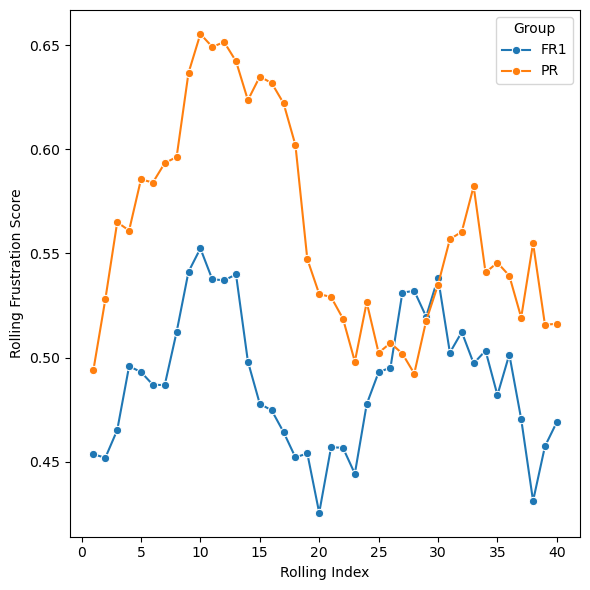

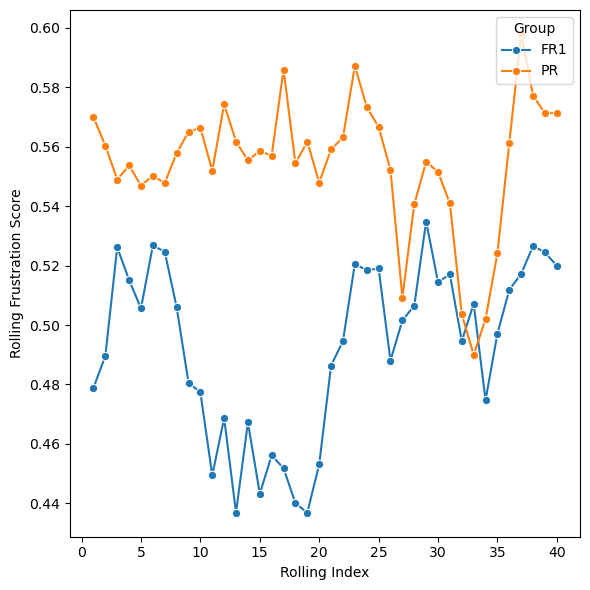

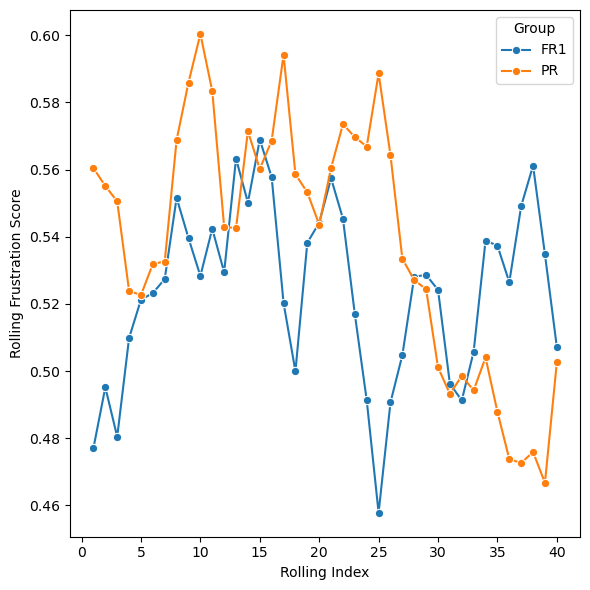

In [165]:
for subject_id in subject_ids:
    make_line_plot(df_single_rolling, subject_id=subject_id)

# GRU

In [159]:
# from modules.nn_models import GRUModel
# from modules.nn_train import dataframe_to_tensors
# import torch

# gru = GRUModel(input_size=1, hidden_size=256, num_layers=4, feature_size=0)

# # load output/gru_models/vgysgbiu/best_model.pt
# gru.load_state_dict(torch.load(f"output/gru_models/vgysgbiu/best_model.pt"))


# device = "cpu"
# nn_test = df_ML_test[['label', 'data']]
# nn_test_x, nn_test_y, nn_test_lengths = dataframe_to_tensors(nn_test, device=device)
# gru.eval()
# with torch.no_grad():
#     y_pred_tensor = gru(nn_test_x, nn_test_lengths)
#     y_pred = y_pred_tensor.squeeze().numpy()
#     # sigmoid to convert logits to probabilities
#     y_pred = 1 / (1 + np.exp(-y_pred)) 

# df_ML_test["gru_prob"] = y_pred[:,1]
# gru_metrics = calc_metrics(y_test, y_pred[:,1], sample_weight=sample_weights_test)
# print(gru_metrics)